# Benchmarking ML v2 — Prediccion de Sobrecosto (Features Reducidas + GPU)

**Dataset:** `docs/contratos_features_reducido.csv` (350 contratos, 33 features)  
**Reduccion:** Top 30 features por RF importance + variables de control (anio, ipc, trm)  
**GPU:** XGBoost con `device='cuda'` en RTX 5060  
**Variable objetivo:** `sobrecosto`  
**Modelos:** Ridge, Lasso, ElasticNet, KNN, DecisionTree, RandomForest, GradientBoosting, XGBoost (+GPU), SVR, MLP  
**Validacion:** Nested CV (5 outer / 5 inner), RandomizedSearchCV (200 iter), HalvingSearchCV  
**XAI:** SHAP, permutation importance, residual analysis

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import time
import re
import joblib
from pathlib import Path

from sklearn.experimental import enable_halving_search_cv

from scipy.stats import randint, uniform, loguniform, ttest_rel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV,
    learning_curve,
    HalvingRandomSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120

RESULTADOS = Path('resultados_v2')
RESULTADOS.mkdir(exist_ok=True)

# Verificar que XGBoost GPU esta disponible
import xgboost as xgb
print('XGBoost version:', xgb.__version__)
try:
    xgb_gpu = xgb.get_config()
    print('GPU disponible para XGBoost: SI')
except:
    print('GPU disponible para XGBoost: NO (usara CPU)')
print('Listo')

XGBoost version: 3.3.0
GPU disponible para XGBoost: SI
Listo


---
## 1. Carga de Dataset Reducido (33 features)

In [42]:
df = pd.read_csv('../docs/contratos_features_reducido.csv')
print(f'Contratos: {len(df)} | Features: {df.shape[1]}')
print(f'Columnas: {list(df.columns)}')
df.head()

Contratos: 350 | Features: 35
Columnas: ['id_contrato', 'sobrecosto', 'tfidf_desarrollo', 'interaccion_prob_x_impacto', 'tfidf_insumos', 'prob_std', 'tfidf_expedicion', 'tfidf_materiales', 'imp_promedio', 'tfidf_cualquier', 'tfidf_ejecucion', 'tfidf_contrato', 'prop_tipo_operacional', 'prob_promedio', 'prop_cate_bajo', 'valor_inicial', 'tfidf_riesgo', 'tfidf_tecnicas', 'tfidf_municipio', 'tfidf_obras', 'tfidf_informacion', 'prop_fuen_externo', 'tfidf_cuando', 'tfidf_disenos', 'tfidf_ejecucion contrato', 'tfidf_calidad', 'tfidf_manejo', 'prop_cate_alto', 'tfidf_pago', 'prop_tipo_economico', 'prop_asig_entidad', 'tfidf_falta', 'anio', 'ipc', 'trm']


,id_contrato,sobrecosto,tfidf_desarrollo,interaccion_prob_x_impacto,tfidf_insumos,prob_std,tfidf_expedicion,tfidf_materiales,imp_promedio,tfidf_cualquier,...,tfidf_calidad,tfidf_manejo,prop_cate_alto,tfidf_pago,prop_tipo_economico,prop_asig_entidad,tfidf_falta,anio,ipc,trm
0,C-001,28.56,0.131124,7.465278,0.000000,0.276385,0.000000,0.000000,3.583333,0.000000,...,0.232896,0.000000,0.666667,0.000000,0.166667,0.083333,0.000000,2018,3.18,2955.7
1,C-002,4.80,0.193673,6.307479,0.000000,0.848659,0.107402,0.000000,3.631579,0.000000,...,0.000000,0.000000,0.263158,0.000000,0.052632,0.315789,0.000000,2019,3.80,3281.1
2,C-003,53.10,0.000000,3.859375,0.000000,0.695971,0.000000,0.306124,1.625000,0.000000,...,0.207766,0.000000,0.125000,0.000000,0.000000,0.125000,0.000000,2019,3.80,3281.1
3,C-004,26.33,0.000000,1.820000,0.117717,0.458258,0.000000,0.000000,1.400000,0.000000,...,0.000000,0.129500,0.000000,0.000000,0.200000,0.100000,0.000000,2018,3.18,2955.7
4,C-005,37.28,0.000000,7.587891,0.052372,0.582961,0.000000,0.086157,3.468750,0.062678,...,0.000000,0.057615,0.781250,0.121007,0.062500,0.125000,0.251524,2019,3.80,3281.1


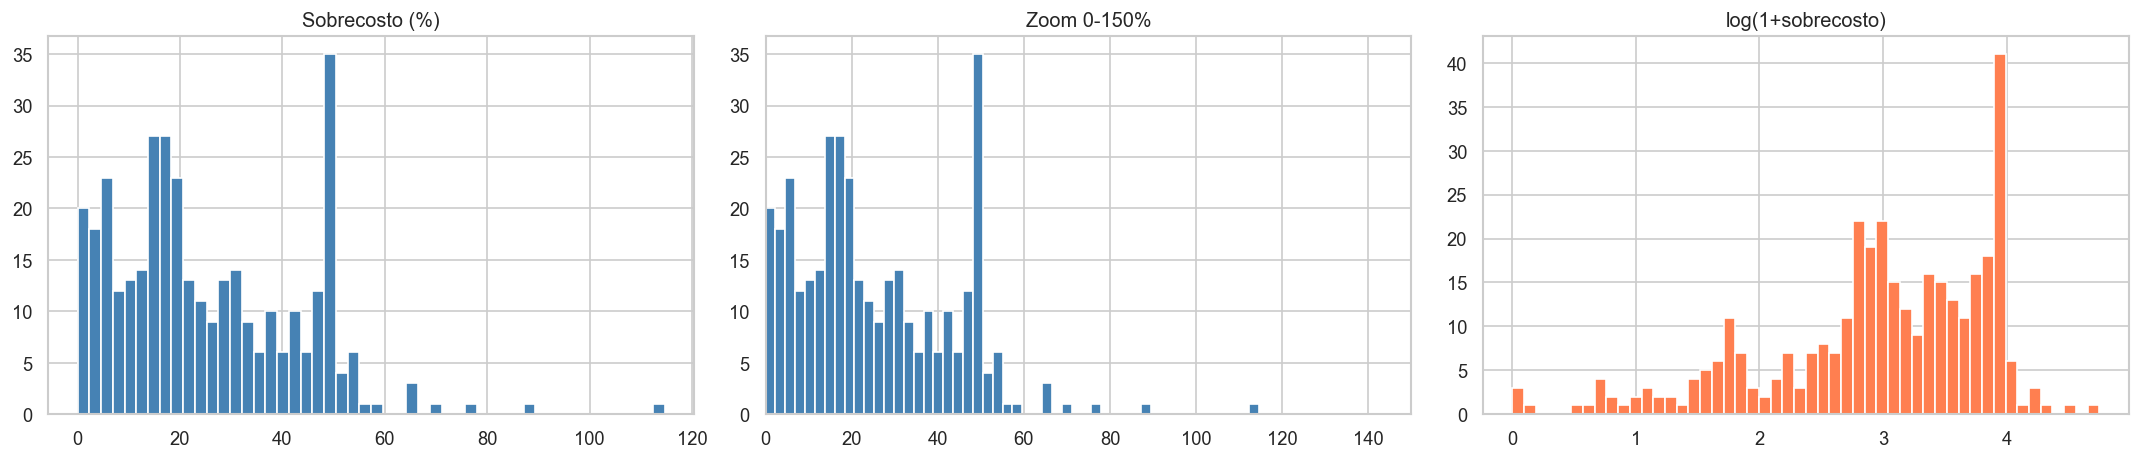

Media: 25.3%  |  >200%: 0 contratos


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df['sobrecosto'], bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('Sobrecosto (%)')
axes[1].hist(df['sobrecosto'], bins=50, edgecolor='white', color='steelblue')
axes[1].set_xlim(0, 150); axes[1].set_title('Zoom 0-150%')
axes[2].hist(np.log1p(df['sobrecosto']), bins=50, edgecolor='white', color='coral')
axes[2].set_title('log(1+sobrecosto)')
plt.tight_layout(); plt.savefig(RESULTADOS / 'target_dist.png', dpi=100, bbox_inches='tight'); plt.show()
media = df['sobrecosto'].mean()
outliers_200 = (df['sobrecosto'] > 200).sum()
print(f'Media: {media:.1f}%  |  >200%: {outliers_200} contratos')

---
## 2. Preparacion Train/Test

In [44]:
target = 'sobrecosto'
feature_cols = [c for c in df.columns if c not in ['id_contrato', target]]
X = df[feature_cols].copy(); y = df[target].copy()
X = X.fillna(X.median())
outliers_mask = y > 200
print(f'Outliers >200% eliminados: {outliers_mask.sum()}')
X_sin = X[~outliers_mask]; y_sin = y[~outliers_mask]
X_train, X_test, y_train, y_test = train_test_split(X_sin, y_sin, test_size=0.3, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_cols)}')

Outliers >200% eliminados: 0
Train: 245 | Test: 105 | Features: 33


---
## 3. Benchmarking — Nested CV

**Grupo 1 — Lineales + KNN** (Ridge, Lasso, ElasticNet, KNN) — 200 iter  
**Grupo 2a — Arboles** (DecisionTree, RandomForest) — 200 iter  
**Grupo 2b — Gradiente** (GradientBoosting, XGBoost GPU) — 200 iter  
**Grupo 3 — SVR + MLP** — 10 iter (los mas lentos)


In [45]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

def rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluar(y_true, y_pred):
    return {'RMSE': rmse(y_true, y_pred), 'MAE': mean_absolute_error(y_true, y_pred), 'R2': r2_score(y_true, y_pred)}

N_ITER = 200

MODELOS = {
    'Ridge': {'m': Ridge(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3)}},
    'Lasso': {'m': Lasso(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3)}},
    'ElasticNet': {'m': ElasticNet(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3), 'm__l1_ratio': uniform(0.1, 0.8)}},
    'KNN': {'m': KNeighborsRegressor(), 'p': {'m__n_neighbors': randint(3, 30), 'm__weights': ['uniform', 'distance'], 'm__p': [1, 2]}},
    'DecisionTree': {'m': DecisionTreeRegressor(random_state=42), 'p': {'m__max_depth': randint(3, 25), 'm__min_samples_split': randint(2, 25), 'm__min_samples_leaf': randint(1, 15), 'm__max_features': ['sqrt', 'log2', None]}},
    'RandomForest': {'m': RandomForestRegressor(random_state=42, n_jobs=-1), 'p': {'m__n_estimators': randint(150, 600), 'm__max_depth': randint(5, 30), 'm__min_samples_split': randint(2, 20), 'm__min_samples_leaf': randint(1, 10), 'm__max_features': ['sqrt', 'log2', None]}},
    'GradientBoosting': {'m': GradientBoostingRegressor(random_state=42), 'p': {'m__n_estimators': randint(100, 500), 'm__max_depth': randint(3, 10), 'm__learning_rate': uniform(0.01, 0.3), 'm__subsample': uniform(0.7, 0.3)}},
    'XGBoost_GPU': {'m': XGBRegressor(random_state=42, verbosity=0, device='cuda', tree_method='hist'), 'p': {'m__max_depth': randint(3, 12), 'm__learning_rate': uniform(0.01, 0.3), 'm__subsample': uniform(0.6, 0.4), 'm__colsample_bytree': uniform(0.6, 0.4), 'm__reg_alpha': loguniform(1e-3, 10), 'm__reg_lambda': loguniform(1e-3, 10), 'm__gamma': uniform(0, 5), 'm__min_child_weight': randint(1, 10)}},
    'SVR': {'m': SVR(), 'p': {'m__kernel': ['rbf', 'poly', 'sigmoid'], 'm__C': loguniform(0.01, 100), 'm__gamma': loguniform(0.001, 10), 'm__epsilon': uniform(0.01, 0.5)}},
    'MLP': {'m': MLPRegressor(random_state=42, max_iter=500, early_stopping=True), 'p': {'m__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)], 'm__activation': ['relu', 'tanh'], 'm__alpha': loguniform(1e-4, 1), 'm__learning_rate_init': loguniform(1e-4, 0.01)}},
}

In [46]:
# === Funcion auxiliar ===
def nested_cv(X, y, md, nombre, n_outer=5, n_inner=5, n_iter=N_ITER):
    outer_cv = KFold(n_splits=n_outer, shuffle=True, random_state=42)
    resultados_outer, tiempos, mejores_params = [], [], []
    for fold, (tr_idx, val_idx) in enumerate(outer_cv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        pipe = Pipeline([('scaler', StandardScaler()), ('m', md['m'])])
        inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=42)
        search = RandomizedSearchCV(pipe, md['p'], n_iter=n_iter, cv=inner_cv,
            scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)
        t0 = time.time(); search.fit(X_tr, y_tr)
        tiempos.append(time.time() - t0); mejores_params.append(search.best_params_)
        resultados_outer.append(evaluar(y_val.values, search.predict(X_val)))
    df_res = pd.DataFrame(resultados_outer)
    return {'modelo': nombre, 'RMSE_mean': df_res['RMSE'].mean(), 'RMSE_std': df_res['RMSE'].std(),
            'MAE_mean': df_res['MAE'].mean(), 'MAE_std': df_res['MAE'].std(),
            'R2_mean': df_res['R2'].mean(), 'R2_std': df_res['R2'].std(),
            'tiempo_mean': np.mean(tiempos), 'best_params': str(mejores_params[0])}, df_res

# === Acumuladores globales ===
resultados, detalles = [], {}
print(f'{"Modelo":20s} {"RMSE":>8s} {"MAE":>8s} {"R2":>7s} {"Tiempo":>8s}')
print('-' * 55)


Modelo                   RMSE      MAE      R2   Tiempo
-------------------------------------------------------


In [47]:
print('=' * 55)
print('  GRUPO 1 — Lineales + KNN (n_iter=200)')
print('=' * 55)
for nombre in ['Ridge', 'Lasso', 'ElasticNet', 'KNN']:
    resumen, df_res = nested_cv(X_train, y_train, MODELOS[nombre], nombre, n_iter=200)
    resultados.append(resumen); detalles[nombre] = df_res
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')


  GRUPO 1 — Lineales + KNN (n_iter=200)
Ridge                  15.6~ 1.1   12.8  0.103~0.080    0.9s
Lasso                  15.9~ 1.2   13.1  0.069~0.091    0.5s
ElasticNet             15.6~ 1.1   12.9  0.094~0.071    0.5s
KNN                    16.2~ 1.2   13.2  0.035~0.061    0.5s


In [48]:
print('=' * 55)
print('  GRUPO 2a — Arboles (n_iter=500)')
print('=' * 55)
for nombre in ['DecisionTree', 'RandomForest']:
    resumen, df_res = nested_cv(X_train, y_train, MODELOS[nombre], nombre, n_iter=500)
    resultados.append(resumen); detalles[nombre] = df_res
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')


  GRUPO 2a — Arboles (n_iter=500)
DecisionTree           17.6~ 2.0   14.6  -0.146~0.156    1.1s
RandomForest           15.7~ 1.3   12.9  0.091~0.097  104.8s


In [49]:
print('=' * 55)
print('  GRUPO 2b — Gradiente (n_iter=200)')
print('=' * 55)
for nombre in ['GradientBoosting', 'XGBoost_GPU']:
    resumen, df_res = nested_cv(X_train, y_train, MODELOS[nombre], nombre, n_iter=200)
    resultados.append(resumen); detalles[nombre] = df_res
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')


  GRUPO 2b — Gradiente (n_iter=200)
GradientBoosting       15.8~ 1.3   12.9  0.072~0.103   33.8s
XGBoost_GPU            15.8~ 1.2   13.0  0.072~0.090  161.5s


In [50]:
print('=' * 55)
print('  GRUPO 3 — SVR + MLP (n_iter=50)')
print('=' * 55)
for nombre in ['SVR', 'MLP']:
    resumen, df_res = nested_cv(X_train, y_train, MODELOS[nombre], nombre, n_iter=50)
    resultados.append(resumen); detalles[nombre] = df_res
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')


  GRUPO 3 — SVR + MLP (n_iter=50)
SVR                    15.8~ 1.1   12.6  0.072~0.036    0.4s
MLP                    16.1~ 2.1   13.1  0.032~0.250    4.0s


In [51]:
df_bench = pd.DataFrame(resultados).set_index('modelo')


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,tiempo_mean
modelo,,,,,,,
Ridge,15.562,1.071,12.843,0.899,0.103,0.080,0.892
Lasso,15.856,1.213,13.100,0.822,0.069,0.091,0.480
ElasticNet,15.649,1.093,12.931,0.985,0.094,0.071,0.481
KNN,16.158,1.209,13.156,0.831,0.035,0.061,0.509
DecisionTree,17.600,1.968,14.599,1.643,-0.146,0.156,1.097
RandomForest,15.673,1.332,12.887,1.051,0.091,0.097,104.791
GradientBoosting,15.827,1.300,12.944,1.034,0.072,0.103,33.847
XGBoost_GPU,15.830,1.163,13.023,1.156,0.072,0.090,161.515
SVR,15.849,1.124,12.622,1.115,0.072,0.036,0.355


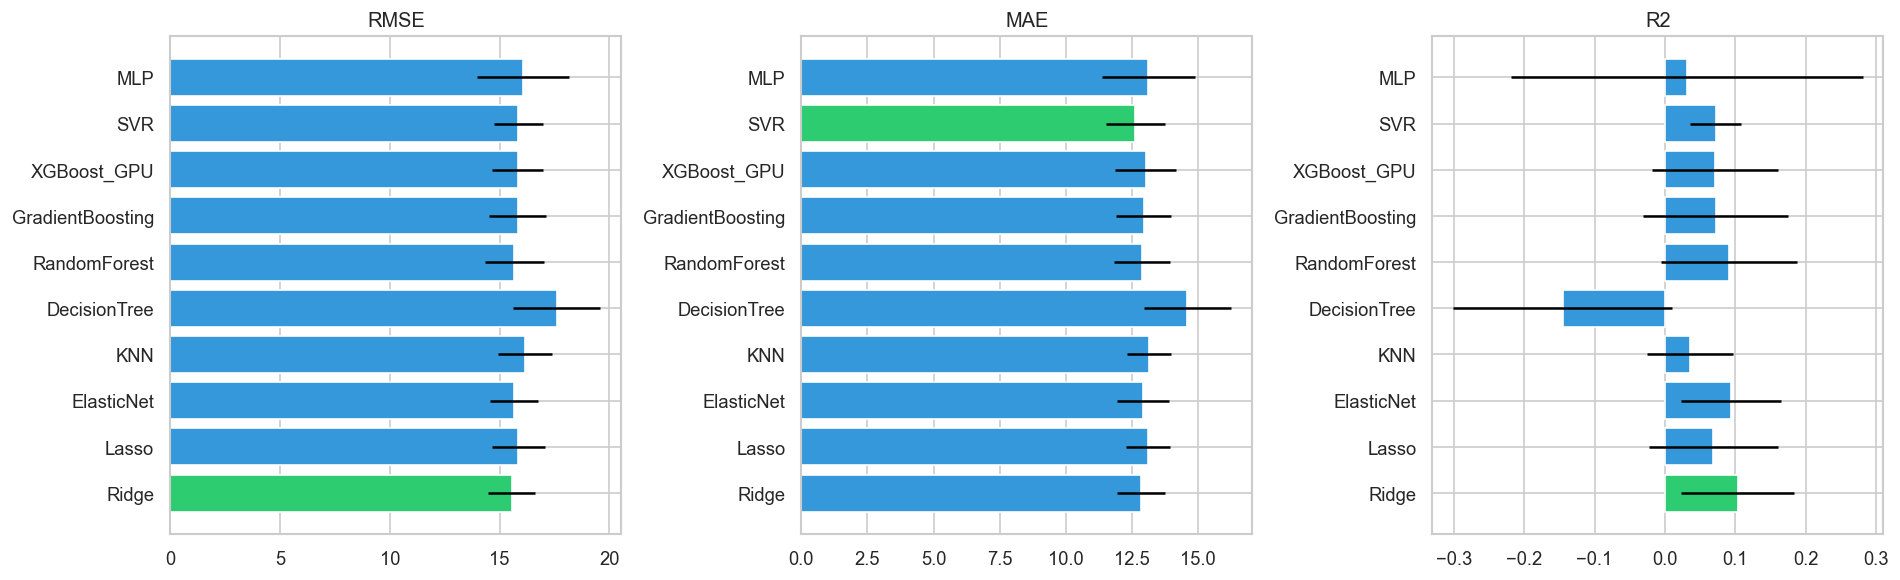


Campeon Nested CV: Ridge (R2=0.103~0.080)


In [52]:
cols = ['RMSE_mean', 'RMSE_std', 'MAE_mean', 'MAE_std', 'R2_mean', 'R2_std', 'tiempo_mean']
display(df_bench[cols].round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, met in enumerate(['RMSE_mean', 'MAE_mean', 'R2_mean']):
    err = met.replace('_mean', '_std')
    best = df_bench[met].min() if 'R2' not in met else df_bench[met].max()
    colors = ['#2ecc71' if v == best else '#3498db' for v in df_bench[met]]
    axes[i].barh(range(len(df_bench)), df_bench[met], xerr=df_bench[err], color=colors, edgecolor='white')
    axes[i].set_yticks(range(len(df_bench))); axes[i].set_yticklabels(df_bench.index)
    axes[i].set_title(met.replace('_mean', ''))
plt.tight_layout(); plt.savefig(RESULTADOS / 'benchmark_comparativo.png', dpi=100, bbox_inches='tight'); plt.show()
mejor_cv = df_bench['R2_mean'].idxmax()
print(f'\nCampeon Nested CV: {mejor_cv} (R2={df_bench.loc[mejor_cv, "R2_mean"]:.3f}~{df_bench.loc[mejor_cv, "R2_std"]:.3f})')

---
## 4. Paired t-test (Top 4)

In [53]:
top4 = df_bench.nlargest(4, 'R2_mean').index.tolist()
print(f'Top 4: {top4}\n')
for i in range(len(top4)):
    for j in range(i + 1, len(top4)):
        ri = detalles[top4[i]]['RMSE']; rj = detalles[top4[j]]['RMSE']
        t, p = ttest_rel(ri, rj)
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'n.s.'
        print(f'  {top4[i]:18s} vs {top4[j]:18s}: t={t:.3f}, p={p:.4f} {sig}')

Top 4: ['Ridge', 'ElasticNet', 'RandomForest', 'SVR']

  Ridge              vs ElasticNet        : t=-1.114, p=0.3276 n.s.
  Ridge              vs RandomForest      : t=-0.246, p=0.8181 n.s.
  Ridge              vs SVR               : t=-0.659, p=0.5460 n.s.
  ElasticNet         vs RandomForest      : t=-0.055, p=0.9588 n.s.
  ElasticNet         vs SVR               : t=-0.510, p=0.6370 n.s.
  RandomForest       vs SVR               : t=-0.376, p=0.7259 n.s.


---
## 5. Optimizacion Extendida (HalvingSearch) + Hold-out

In [54]:
mejor_idx = df_bench['R2_mean'].idxmax()
mejor_def = MODELOS[mejor_idx]

pipe = Pipeline([('scaler', StandardScaler()), ('m', mejor_def['m'])])

halving = HalvingRandomSearchCV(pipe, mejor_def['p'], cv=5, n_candidates=30, factor=2,
    scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)
halving.fit(X_train, y_train)

print(f'Mejores params ({mejor_idx}):')
for k, v in halving.best_params_.items(): print(f'  {k}: {v}')

y_pred = halving.predict(X_test)
print(f'\nHold-out: RMSE={np.sqrt(mean_squared_error(y_test, y_pred)):.2f}  MAE={mean_absolute_error(y_test, y_pred):.2f}  R2={r2_score(y_test, y_pred):.3f}')

joblib.dump(halving.best_estimator_, RESULTADOS / 'modelo_campeon_halving.pkl')
print('Modelo guardado en resultados_v2/modelo_campeon_halving.pkl')

Mejores params (Ridge):
  m__alpha: 98.77700294007911

Hold-out: RMSE=20.82  MAE=16.13  R2=-0.043
Modelo guardado en resultados_v2/modelo_campeon_halving.pkl


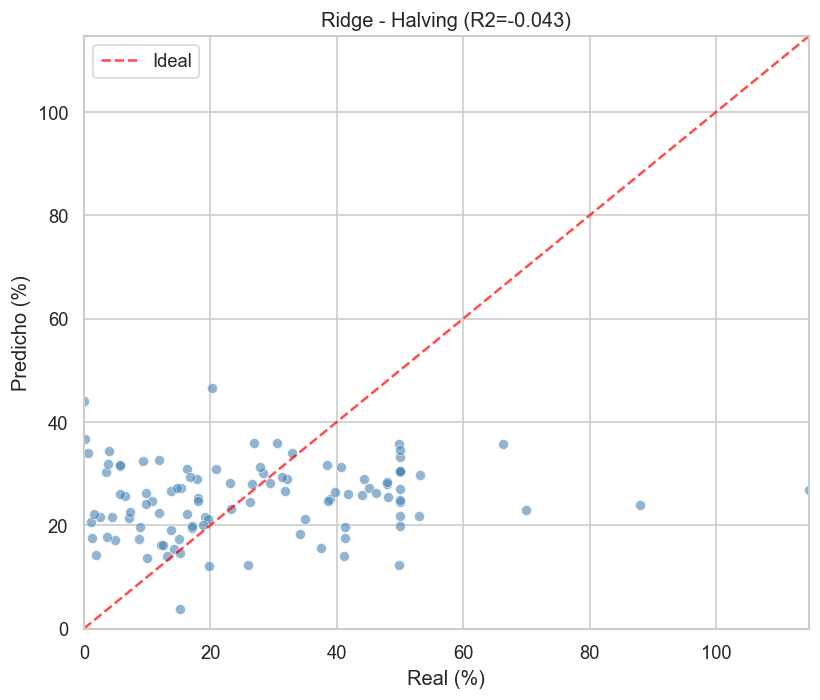

In [55]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='white', linewidth=0.5, c='steelblue')
lims = [0, max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', alpha=0.7, label='Ideal')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Real (%)'); ax.set_ylabel('Predicho (%)')
ax.set_title(f'{mejor_idx} - Halving (R2={r2_score(y_test, y_pred):.3f})')
ax.legend(); plt.tight_layout()
plt.savefig(RESULTADOS / 'holdout_scatter.png', dpi=100, bbox_inches='tight'); plt.show()

---
## 6. Seleccion Multiobjetivo (Precision-Robustez-Complejidad-Interpretabilidad)

In [56]:
proxy_complejidad = {
    'Ridge': 2, 'Lasso': 2, 'ElasticNet': 2,
    'KNN': 1, 'DecisionTree': 2,
    'RandomForest': 3, 'GradientBoosting': 3, 'XGBoost_GPU': 3,
    'SVR': 2, 'MLP': 3
}
proxy_interpretabilidad = {
    'Ridge': 5, 'Lasso': 5, 'ElasticNet': 4,
    'KNN': 4, 'DecisionTree': 5,
    'RandomForest': 4, 'GradientBoosting': 3, 'XGBoost_GPU': 3,
    'SVR': 2, 'MLP': 1
}

df_seleccion = df_bench[['R2_mean', 'RMSE_std', 'tiempo_mean']].copy()
df_seleccion['complejidad'] = [proxy_complejidad[m] for m in df_seleccion.index]
df_seleccion['interpretabilidad'] = [proxy_interpretabilidad[m] for m in df_seleccion.index]
df_seleccion['score_balance'] = (
    df_seleccion['R2_mean'] * 0.4
    - df_seleccion['RMSE_std'] * 0.0005
    - df_seleccion['tiempo_mean'] * 0.001
    - df_seleccion['complejidad'] * 0.05
    + df_seleccion['interpretabilidad'] * 0.05
)
print('=== SELECCION MULTIOBJETIVO ===')
print(f'{"Modelo":20s} {"R2":>6s} {"R2_std":>6s} {"T(s)":>6s} {"Comp":>4s} {"Interp":>4s} {"Score":>7s}')
print('-' * 60)
for idx, r in df_seleccion.sort_values('score_balance', ascending=False).iterrows():
    print(f'{idx:20s} {r["R2_mean"]:5.3f}  {r["RMSE_std"]:5.2f} {r["tiempo_mean"]:5.0f}  {int(r["complejidad"]):4d} {int(r["interpretabilidad"]):5d} {r["score_balance"]:6.3f}')

print(f'\nCampeon por R2 puro: {df_bench["R2_mean"].idxmax()}')
top_balance = df_seleccion['score_balance'].idxmax()
print(f'Campeon multiobjetivo: {top_balance} (score={df_seleccion.loc[top_balance, "score_balance"]:.3f})')
conclusion = "Coinciden ambos criterios" if top_balance == df_bench["R2_mean"].idxmax() else "El multiobjetivo favorece a " + top_balance + " por mejor balance precision-robustez-complejidad-interpretabilidad"
print(f'Conclusion: {conclusion}')

=== SELECCION MULTIOBJETIVO ===
Modelo                   R2 R2_std   T(s) Comp Interp   Score
------------------------------------------------------------
Ridge                0.103   1.07     1     2     5  0.190
Lasso                0.069   1.21     0     2     5  0.177
KNN                  0.035   1.21     1     1     4  0.163
ElasticNet           0.094   1.09     0     2     4  0.137
DecisionTree         -0.146   1.97     1     2     5  0.090
SVR                  0.072   1.12     0     2     2  0.028
GradientBoosting     0.072   1.30    34     3     3 -0.006
RandomForest         0.091   1.33   105     3     4 -0.019
MLP                  0.032   2.08     4     3     1 -0.092
XGBoost_GPU          0.072   1.16   162     3     3 -0.133

Campeon por R2 puro: Ridge
Campeon multiobjetivo: Ridge (score=0.190)
Conclusion: Coinciden ambos criterios


---
## 7. Learning Curve

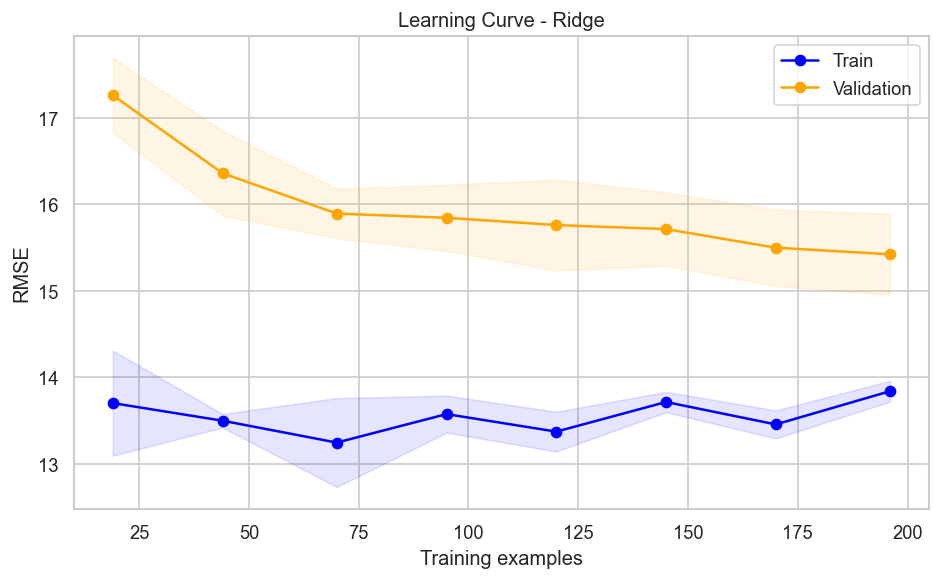

In [57]:
train_sizes = np.linspace(0.1, 1.0, 8)
lc = learning_curve(halving.best_estimator_, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error', train_sizes=train_sizes, n_jobs=-1)
ts = lc[0]; train_mean = -lc[1].mean(axis=1); train_std = lc[1].std(axis=1)
test_mean = -lc[2].mean(axis=1); test_std = lc[2].std(axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(ts, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax.fill_between(ts, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
ax.plot(ts, train_mean, 'o-', label='Train', color='blue')
ax.plot(ts, test_mean, 'o-', label='Validation', color='orange')
ax.set_xlabel('Training examples'); ax.set_ylabel('RMSE')
ax.set_title(f'Learning Curve - {mejor_idx}'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTADOS / 'learning_curve.png', dpi=100, bbox_inches='tight'); plt.show()

---
## 8. Residual Analysis

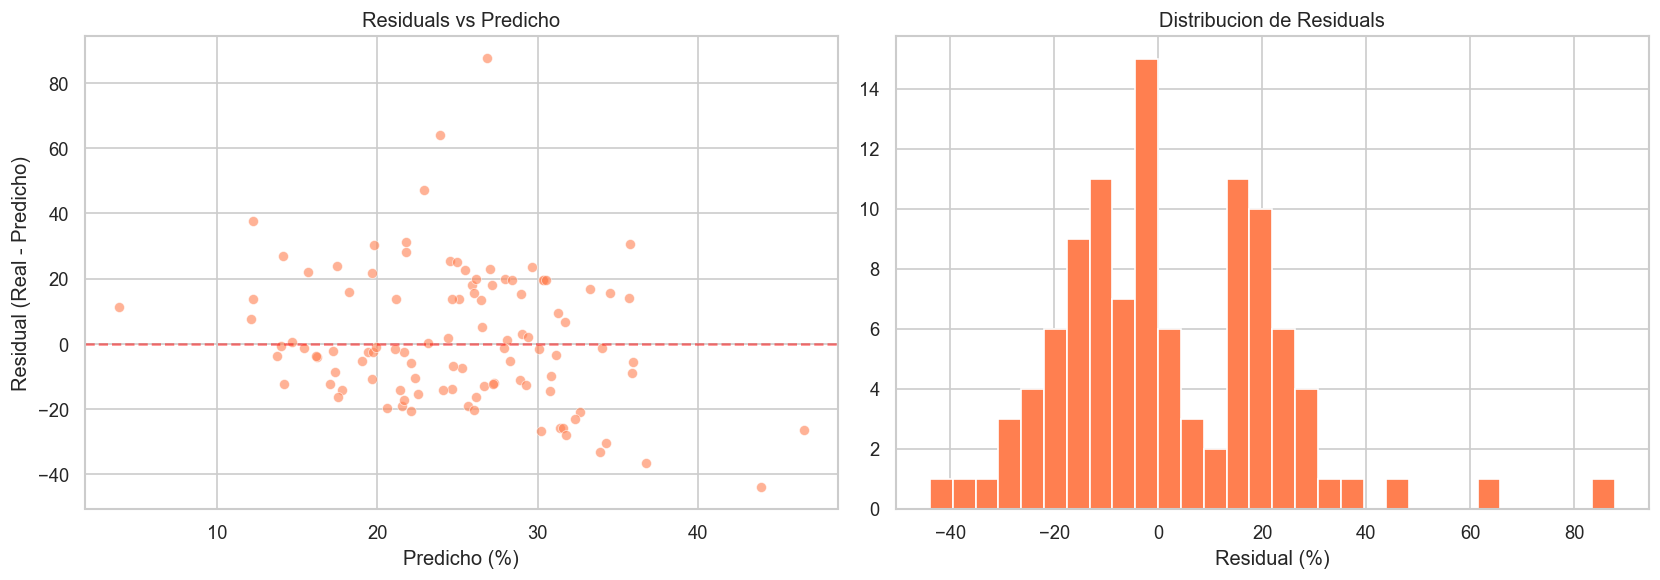

Residuals: mean=1.7%, std=20.9%


In [58]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.6, edgecolors='white', linewidth=0.5, c='coral')
axes[0].axhline(0, color='red', ls='--', alpha=0.5)
axes[0].set_xlabel('Predicho (%)'); axes[0].set_ylabel('Residual (Real - Predicho)')
axes[0].set_title('Residuals vs Predicho')
axes[1].hist(residuals, bins=30, edgecolor='white', color='coral')
axes[1].set_xlabel('Residual (%)'); axes[1].set_title('Distribucion de Residuals')
plt.tight_layout(); plt.savefig(RESULTADOS / 'residuals.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'Residuals: mean={residuals.mean():.1f}%, std={residuals.std():.1f}%')

---
## 9. SHAP Analysis

Background dataset has 105 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=105 when initializing the masker.


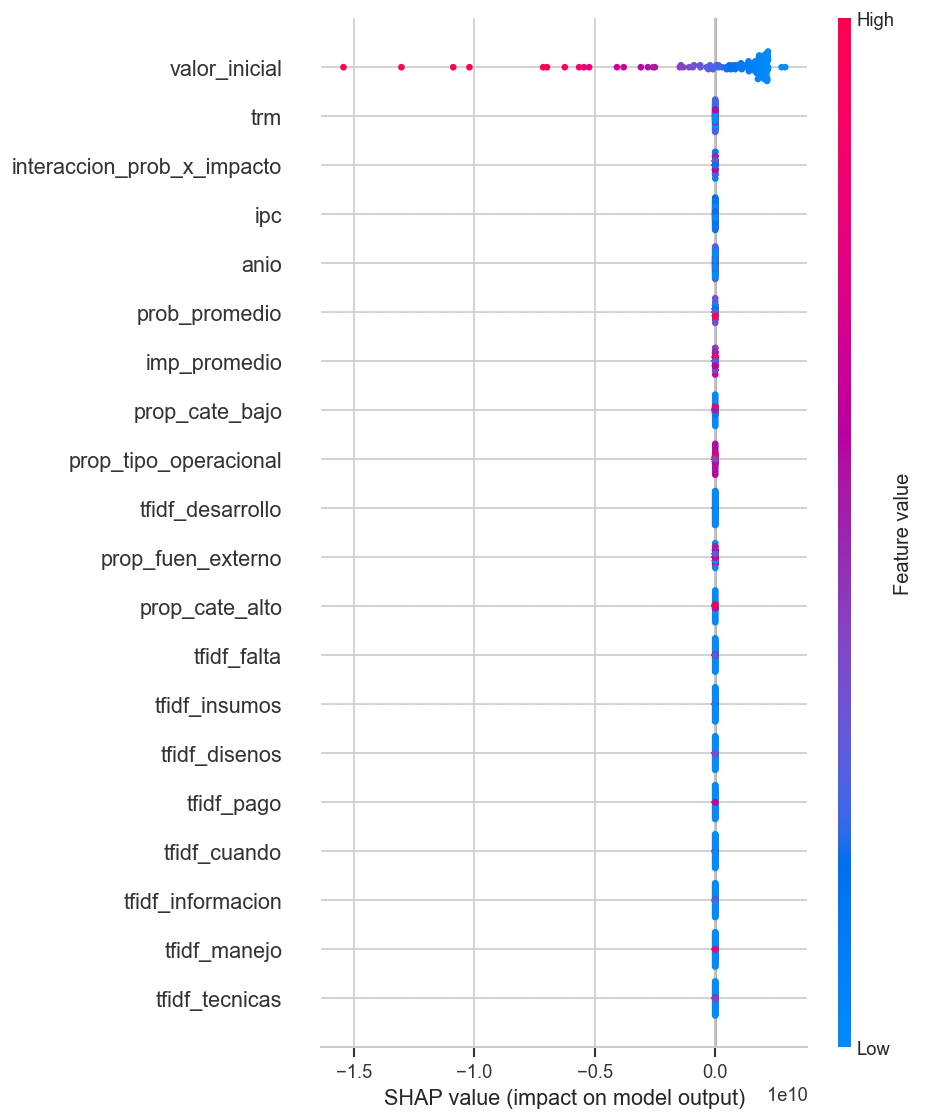

SHAP summary guardado.


In [59]:
import shap

final_model = halving.best_estimator_

if hasattr(final_model.named_steps['m'], 'feature_importances_'):
    imp = final_model.named_steps['m'].feature_importances_
    feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': imp})
    feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(feat_imp)), feat_imp['importance'][::-1], color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(feat_imp))); ax.set_yticklabels(feat_imp['feature'][::-1])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Features - {mejor_idx}')
    plt.tight_layout(); plt.savefig(RESULTADOS / 'shap_importance.png', dpi=100, bbox_inches='tight'); plt.show()

try:
    explainer = shap.Explainer(final_model.named_steps['m'], X_test)
    shap_values = explainer(X_test)
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.savefig(RESULTADOS / 'shap_summary.png', dpi=100, bbox_inches='tight'); plt.show()
    print('SHAP summary guardado.')
except Exception as e:
    print(f'SHAP no disponible para este modelo: {e}')

---
## 10. Resumen Final

In [60]:
print('=' * 60)
print('  RESUMEN FINAL - MODELADO V2 (33 FEATURES)')
print('=' * 60)
print(f'Dataset: {len(df)} contratos | Features: {len(feature_cols)}')
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'\nBenchmarking (Nested CV 5x5, {N_ITER} iter):')
print(f'{"Modelo":20s} {"RMSE":>8s} {"R2":>8s} {"T(s)":>8s}')
print('-' * 46)
for idx, r in df_bench.iterrows():
    print(f'{idx:20s} {r["RMSE_mean"]:6.1f}~{r["RMSE_std"]:4.1f} {r["R2_mean"]:6.3f}~{r["R2_std"]:4.3f} {r["tiempo_mean"]:6.1f}s')

print(f'\nModelo campeon R2: {df_bench["R2_mean"].idxmax()}')
mejor = df_bench.loc[df_bench['R2_mean'].idxmax()]
print(f'  R2 Nested CV: {mejor["R2_mean"]:.3f} +- {mejor["R2_std"]:.3f}')
print(f'  RMSE Nested CV: {mejor["RMSE_mean"]:.1f} +- {mejor["RMSE_std"]:.1f}')

print(f'\nSeleccion Multiobjetivo:')
top_b = df_seleccion['score_balance'].idxmax()
print(f'  Campeon balanceado: {top_b}')

  RESUMEN FINAL - MODELADO V2 (33 FEATURES)
Dataset: 350 contratos | Features: 33
Train: 245 | Test: 105

Benchmarking (Nested CV 5x5, 200 iter):
Modelo                   RMSE       R2     T(s)
----------------------------------------------
Ridge                  15.6~ 1.1  0.103~0.080    0.9s
Lasso                  15.9~ 1.2  0.069~0.091    0.5s
ElasticNet             15.6~ 1.1  0.094~0.071    0.5s
KNN                    16.2~ 1.2  0.035~0.061    0.5s
DecisionTree           17.6~ 2.0 -0.146~0.156    1.1s
RandomForest           15.7~ 1.3  0.091~0.097  104.8s
GradientBoosting       15.8~ 1.3  0.072~0.103   33.8s
XGBoost_GPU            15.8~ 1.2  0.072~0.090  161.5s
SVR                    15.8~ 1.1  0.072~0.036    0.4s
MLP                    16.1~ 2.1  0.032~0.250    4.0s

Modelo campeon R2: Ridge
  R2 Nested CV: 0.103 +- 0.080
  RMSE Nested CV: 15.6 +- 1.1

Seleccion Multiobjetivo:
  Campeon balanceado: Ridge


---
## 11. Optimizacion — Log-target + Interacciones + Coeficientes Ridge

Aplicando los 3 pasos del asesor para subir el R2:
1. **Log-transform** del target (estabiliza varianza de cola larga)
2. **Interacciones** TRM/IPC con variables de riesgo
3. **Coeficientes Ridge** + limpieza de features con peso ~0


In [61]:
print('=' * 60)
print('  PASO 1 + 2: INTERACCIONES + LOG-TARGET')
print('=' * 60)

# Recargar datos
df_opt = df.copy()

# Interacciones TRM/IPC con variables de riesgo
df_opt['trm_x_prob_std'] = df_opt['trm'] * df_opt['prob_std']
df_opt['ipc_x_valor_inicial'] = df_opt['ipc'] * df_opt['valor_inicial']
df_opt['trm_x_interaccion'] = df_opt['trm'] * df_opt['interaccion_prob_x_impacto']
print(f'Interacciones agregadas: +3 columnas')

# Train/test split con log-target
target = 'sobrecosto'
feature_cols_opt = [c for c in df_opt.columns if c not in ['id_contrato', target]]
X_opt = df_opt[feature_cols_opt].copy()
y_opt_orig = df_opt[target].copy()
y_opt_log = np.log1p(y_opt_orig)

X_tr_opt, X_te_opt, y_tr_orig, y_te_orig = train_test_split(X_opt, y_opt_orig, test_size=0.2, random_state=42)
_, _, y_tr_log, y_te_log = train_test_split(X_opt, y_opt_log, test_size=0.2, random_state=42)

print(f'Train: {len(X_tr_opt)} | Test: {len(X_te_opt)} | Features: {X_tr_opt.shape[1]}')

# Evaluador que back-transforma del log al original
def evaluar_opt(y_true_orig, y_pred_log):
    y_pred_orig = np.expm1(y_pred_log)
    return {'RMSE': rmse(y_true_orig, y_pred_orig),
            'MAE': mean_absolute_error(y_true_orig, y_pred_orig),
            'R2': r2_score(y_true_orig, y_pred_orig)}

# Nested CV wrapper para log-target
def nested_cv_opt(X, y_log, y_orig, md, nombre, n_iter=200):
    outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    resultados_outer, tiempos = [], []
    for tr_idx, val_idx in outer_cv.split(X):
        X_tr_f, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr_f = y_log.iloc[tr_idx]
        y_val_orig = y_orig.iloc[val_idx]
        pipe = Pipeline([('scaler', StandardScaler()), ('m', md['m'])])
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
        search = RandomizedSearchCV(pipe, md['p'], n_iter=n_iter, cv=inner_cv,
            scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)
        t0 = time.time(); search.fit(X_tr_f, y_tr_f)
        tiempos.append(time.time() - t0)
        preds_log = search.predict(X_val)
        resultados_outer.append(evaluar_opt(y_val_orig.values, preds_log))
    df_res = pd.DataFrame(resultados_outer)
    return {'modelo': nombre, 'RMSE_mean': df_res['RMSE'].mean(), 'RMSE_std': df_res['RMSE'].std(),
            'MAE_mean': df_res['MAE'].mean(), 'MAE_std': df_res['MAE'].std(),
            'R2_mean': df_res['R2'].mean(), 'R2_std': df_res['R2'].std(),
            'tiempo_mean': np.mean(tiempos)}, df_res

# Solo probamos los 3 mejores: Ridge, ElasticNet, RandomForest
print(f'\n{"Modelo":20s} {"RMSE":>8s} {"MAE":>8s} {"R2":>7s} {"Tiempo":>8s}')
print('-' * 55)
resultados_opt = []
for nombre in ['Ridge', 'ElasticNet', 'RandomForest']:
    resumen, df_res = nested_cv_opt(X_tr_opt, y_tr_log, y_tr_orig, MODELOS[nombre], nombre, n_iter=200)
    resultados_opt.append(resumen)
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')

df_opt_bench = pd.DataFrame(resultados_opt).set_index('modelo')
print(f'\n--- Mejora vs Original ---')
for nombre in ['Ridge', 'ElasticNet', 'RandomForest']:
    if nombre in df_bench.index:
        orig_r2 = df_bench.loc[nombre, 'R2_mean']
        opt_r2 = df_opt_bench.loc[nombre, 'R2_mean'] if nombre in df_opt_bench.index else 0
        diff = opt_r2 - orig_r2
        emoji = '+' if diff > 0 else ''
        print(f'{nombre:20s}: R2 orig={orig_r2:.3f}  ->  R2 opt={opt_r2:.3f}  ({emoji}{diff:.3f})')


  PASO 1 + 2: INTERACCIONES + LOG-TARGET
Interacciones agregadas: +3 columnas
Train: 280 | Test: 70 | Features: 36

Modelo                   RMSE      MAE      R2   Tiempo
-------------------------------------------------------
Ridge                  18.5~ 2.6   14.2  -0.094~0.072    0.4s
ElasticNet             18.8~ 2.4   14.4  -0.133~0.051    0.5s
RandomForest           18.3~ 2.6   14.0  -0.067~0.085   44.7s

--- Mejora vs Original ---
Ridge               : R2 orig=0.103  ->  R2 opt=-0.094  (-0.198)
ElasticNet          : R2 orig=0.094  ->  R2 opt=-0.133  (-0.227)
RandomForest        : R2 orig=0.091  ->  R2 opt=-0.067  (-0.158)


In [62]:
print('=' * 60)
print('  PASO 3: COEFICIENTES RIDGE + LIMPIEZA DE FEATURES')
print('=' * 60)

# Entrenar Ridge final con todos los datos de train
from sklearn.linear_model import RidgeCV

scaler_opt = StandardScaler()
X_tr_scaled = scaler_opt.fit_transform(X_tr_opt)

ridge_opt = RidgeCV(alphas=np.logspace(-3, 3, 50), scoring='neg_root_mean_squared_error')
ridge_opt.fit(X_tr_scaled, y_tr_log)
print(f'Alpha optimo: {ridge_opt.alpha_:.4f}')

# Coeficientes en escala original (despues de scaler)
coefs_ridge = pd.DataFrame({
    'feature': X_tr_opt.columns,
    'coef': ridge_opt.coef_
}).sort_values('coef', ascending=False)

print(f'\n--- TOP 10 que AUMENTAN el sobrecosto ---')
print(coefs_ridge.head(10).to_string(index=False))
print(f'\n--- TOP 10 que DISMINUYEN el sobrecosto ---')
print(coefs_ridge.tail(10).to_string(index=False))

# Limpieza: features con coef ≈ 0
zero_coefs = coefs_ridge[np.abs(coefs_ridge['coef']) < 0.001]
print(f'\nFeatures con coef ~0 ({len(zero_coefs)}): {list(zero_coefs["feature"])}')

features_keep = coefs_ridge[np.abs(coefs_ridge['coef']) >= 0.001]['feature'].tolist()
print(f'Features a mantener: {len(features_keep)}')

# Re-entrenar Ridge solo con features importantes
X_tr_clean = X_tr_opt[features_keep]
X_te_clean = X_te_opt[features_keep]

scaler_clean = StandardScaler()
X_tr_clean_scaled = scaler_clean.fit_transform(X_tr_clean)
X_te_clean_scaled = scaler_clean.transform(X_te_clean)

ridge_clean = RidgeCV(alphas=np.logspace(-3, 3, 50), scoring='neg_root_mean_squared_error')
ridge_clean.fit(X_tr_clean_scaled, y_tr_log)
preds_log = ridge_clean.predict(X_te_clean_scaled)
res_clean = evaluar_opt(y_te_orig.values, preds_log)

print(f'\n--- Ridge post-limpieza (Hold-out) ---')
print(f'RMSE: {res_clean["RMSE"]:.1f} | MAE: {res_clean["MAE"]:.1f} | R2: {res_clean["R2"]:.3f}')
print(f'Features eliminadas: {len(zero_coefs)}')


  PASO 3: COEFICIENTES RIDGE + LIMPIEZA DE FEATURES
Alpha optimo: 568.9866

--- TOP 10 que AUMENTAN el sobrecosto ---
              feature     coef
           tfidf_pago 0.036475
     tfidf_desarrollo 0.033569
        tfidf_disenos 0.030827
        tfidf_calidad 0.027519
prop_tipo_operacional 0.022312
       tfidf_tecnicas 0.022239
       prop_cate_alto 0.021846
          tfidf_falta 0.018592
        prob_promedio 0.015980
          tfidf_obras 0.014189

--- TOP 10 que DISMINUYEN el sobrecosto ---
                 feature      coef
tfidf_ejecucion contrato -0.015186
         tfidf_municipio -0.016991
        tfidf_materiales -0.019179
                prob_std -0.019234
          trm_x_prob_std -0.022005
         tfidf_ejecucion -0.026723
         tfidf_cualquier -0.034394
           tfidf_insumos -0.034396
            tfidf_manejo -0.044413
       tfidf_informacion -0.048966

Features con coef ~0 (1): ['prop_cate_bajo']
Features a mantener: 35

--- Ridge post-limpieza (Hold-out) ---
R